# Continuous Gesture Recognition from Forearm sEMG with TENNs-R

This notebook is an **educational, self-contained tutorial**. It walks through a complete
always-on sensing problem, surface electromyography (sEMG) gesture recognition on the public
**NinaPro DB2** dataset, and shows how BrainChip's **TENNs-R** state space model solves it in
**96,128 parameters** at **int8**.

Everything the notebook needs is either defined in its own cells or shipped next to it. There are
no imports from a helper module, so you can read the whole pipeline in one place and re-run every
figure.

**What you will see**

1. What the raw 12-channel sEMG stream looks like, and why a *continuous* stream is a harder problem
   than the pre-cut windows the published benchmarks use.
2. How the model is trained and how it is scored, rebuilt as a figure from the shipped data.
3. Post-training quantization to int8, calibrated on streams so the recurrent state is charged.
4. Conversion with `cnn2snn` and a real mapping attempt against **Akida Pico**, including the
   constraints the mapper enforces and the Pico IP configuration this model needs.
5. Streaming inference over held-out data, a wake trigger built from the model's own output, and
   the 40-subject result set against the published DB2 literature.

**Headline result.** Averaged over all 40 DB2 subjects, the int8 model reaches
**85.31 %, standard deviation 4.37** on the 49 gesture classes, against a float equivalent of
**85.39 %, standard deviation 4.40**. Chance on this task is about 2 %.

> **About the hardware in this notebook.** The other examples in this repository run on the Akida
> Pico FPGA and report frames per second and power. **This model does not fit the shipped Pico FPGA
> today**, so there are no throughput, latency or power numbers here, and the notebook does not
> invent any. Section 10 runs the real mapper, shows exactly which memories overflow, and states the
> Pico IP configuration that accommodates the model. Everything else in the notebook, including
> every accuracy figure, runs end to end on the CPU with the same MetaTF toolchain.

**Pipeline:** dataset -> model -> stateful conversion -> int8 quantization -> Akida conversion and
Pico budget -> streaming inference -> trigger -> results. **Run the cells in order.**


## 1. The use case: always-on gesture recognition from forearm sEMG

Surface EMG electrodes on the forearm pick up the electrical activity of the muscles that move the
hand. Decode that activity and you can drive a prosthesis, a wearable controller or a
hands-free interface directly from intent, without a camera and without the user touching anything.

A product has to answer two questions at once, continuously:

- **Is a gesture happening right now?** Most of the day the hand is at rest. The system must stay
  quiet through all of it.
- **Which gesture is it?** Once something is happening, name it quickly enough that the response
  feels immediate.

That is an always-on problem, and it sets the engineering constraints: the sensing path runs from a
battery, it never gets to buffer the day and process it later, and it must not wake the rest of the
system for nothing.

**How this differs from the benchmark literature.** Published DB2 results classify an isolated
**200 ms window drawn from a labelled movement**. Rest is not one of their classes, so a rest window
cannot even be presented to them, and the population they score is movement windows only. That
measures "given that a gesture is happening, and given a slice of it, can you name it".

This notebook scores something harder and closer to a product: the model is fed a **continuous
stream** and emits a decision **every 8 ms**, including the onset transition where the muscle has
barely activated, and it carries a rest class so it can also say "nothing is happening". Section 13
comes back to this and states plainly what is and is not comparable.


## 2. Imports and paths

The toolchain is the standard MetaTF stack: **quantizeml** for quantization, **akida_models** for
the layer blocks and the stateful conversion, **cnn2snn** to convert into an Akida model, and
**akida** for the Pico device and the mapper.

`BASE_DIR` is the folder holding this notebook, so the shipped weights, calibration streams,
held-out segments and results tables are found relative to it.


In [1]:
# The package versions this notebook was executed against. The Akida Cloud image normally
# satisfies these already, so uncomment and run this cell only if an import below fails.
# %pip install akida==2.19.2 cnn2snn==2.19.2 quantizeml==1.2.4 akida_models==1.14.1 \
#              tensorflow==2.19.1 numpy matplotlib


In [2]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import csv
import time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from matplotlib.patches import Patch, Rectangle

import akida
import cnn2snn
import quantizeml
from akida_models.layer_blocks import kernelized_block
from akida_models.tenn_recurrent.convert_recurrent import convert_to_stateful
from quantizeml.layers import reset_states, update_batch_size
from quantizeml.models import QuantizationParams
from tf_keras.layers import Input, Rescaling, SpatialDropout1D
from tf_keras.models import Model

tf.get_logger().setLevel("ERROR")   # quantizeml traces one graph per stateful layer, which TF reports as excessive retracing

BASE_DIR = os.getcwd()

SAMPLE_RATE = 2000          # Hz, the DB2 acquisition rate
CHUNK = 16                  # input samples consumed per output step
STEP_MS = CHUNK / SAMPLE_RATE * 1000.0      # 8.0 ms between decisions
NUM_CLASSES = 50            # 49 gestures plus rest
REST = 0                    # the rest class id
NUM_CHANNELS = 12           # electrodes in DB2
DEPLOY_CHANNELS = 16        # Pico needs a power-of-two packed input row
TRAIN_LENGTH = 8208         # training crop for this subject, in input samples
SUBJECT = 23

print(f"akida {akida.__version__}, cnn2snn {cnn2snn.__version__}, "
      f"quantizeml {quantizeml.__version__}, tensorflow {tf.__version__}")
print(f"one decision every {STEP_MS:.0f} ms, {1000.0 / STEP_MS:.0f} decisions per second")


akida 2.19.2, cnn2snn 2.19.2, quantizeml 1.2.4, tensorflow 2.19.1
one decision every 8 ms, 125 decisions per second


In [3]:
PALETTE = {
    "signal": "#1f3b63",
    "rest": "#eceff3",
    "movement": "#2f6fb2",
    "test": "#e8a33d",
    "accent": "#d2601a",
    "ours": "#0b6bcb",
    "other": "#9aa7b4",
    "grid": "#d8dde3",
}

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#8b959f",
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": PALETTE["grid"],
    "grid.linewidth": 0.6,
    "font.size": 10,
    "legend.frameon": False,
})


## 3. The dataset: NinaPro DB2

NinaPro DB2 is the standard public benchmark for sEMG gesture recognition.

| Property | Value |
|---|---|
| Subjects | 40 intact subjects |
| Sensors | 12 Delsys Trigno wireless electrodes on the forearm and upper arm |
| Sample rate | 2 kHz per channel |
| Movements | 49, grouped into three exercise blocks of 17, 23 and 9, plus a rest class |
| Repetitions | 6 of every movement |
| Structure | each repetition is about 5 s of movement followed by about 3 s of rest |

Electrodes 1 to 8 are spaced evenly around the forearm, 9 and 10 sit on the flexor and extensor
digitorum superficialis, and 11 and 12 on the biceps and triceps. The release ships a realigned
label track (`restimulus`) in which the movement boundaries were corrected offline, and every
published result uses it.

**What is shipped with this notebook.** Subject 23's held-out repetitions, already converted to the
int16 form the model consumes, using that subject's own per-channel scale fitted on the training
repetitions. The full archive is a 463 MiB download for this subject, from
`https://ninapro.hevs.ch/files/DB2_Preproc/DB2_s23.zip`; the README explains how each shipped file
was produced from it.


In [4]:
def load_test_segments(path):
    """Load subject 23's held-out passes and the per-step label columns that go with them.

    Args:
        path: path to the shipped test-segment archive.

    Returns:
        Dict with the int16 streams, and per-pass label, since-onset, gesture and repetition
        columns. Each stream is one repetition segment: half the preceding rest, the movement,
        half the following rest.
    """
    archive = np.load(path)
    lengths = archive["length"]
    bounds = np.cumsum(archive["step_counts"])[:-1]
    return {
        "streams": [archive["emg"][i, : lengths[i]] for i in range(lengths.size)],
        "labels": np.split(archive["labels"], bounds),
        "since_onset_ms": np.split(archive["since_onset_ms"], bounds),
        "gesture": archive["gesture"],
        "repetition": archive["repetition"],
        "discard_chunks": int(archive["discard_chunks"]),
    }


test = load_test_segments(os.path.join(BASE_DIR, "test_data", "db2_s23_test_segments.npz"))
total_samples = sum(stream.shape[0] for stream in test["streams"])
total_steps = sum(labels.size for labels in test["labels"])

print(f"{len(test['streams'])} held-out passes for subject {SUBJECT} "
      f"(49 gestures x repetitions 2 and 5)")
print(f"{total_samples:,} input samples = {total_samples / SAMPLE_RATE / 60:.1f} minutes of signal")
print(f"{total_steps:,} scored decisions after the 1 s cold-start discard of each pass")
print(f"pass lengths: {min(s.shape[0] for s in test['streams']) / SAMPLE_RATE:.1f} s to "
      f"{max(s.shape[0] for s in test['streams']) / SAMPLE_RATE:.1f} s")


98 held-out passes for subject 23 (49 gestures x repetitions 2 and 5)
1,682,688 input samples = 14.0 minutes of signal
92,918 scored decisions after the 1 s cold-start discard of each pass
pass lengths: 7.3 s to 10.2 s


### Figure: one held-out pass, all 12 channels

One repetition segment of real signal. The shaded band is the labelled movement; everything outside
it is rest.

Three things to notice. The movement does not switch on cleanly, it ramps, and that ramp is where a
streaming model has to commit to an answer. Different electrodes carry very different amounts of
this gesture, because a gesture recruits some muscles and not others. And each channel here has
already been divided by its own full-scale value, fitted on that subject's training repetitions,
which is why a quiet channel's baseline noise looks as large as a busy channel's signal. Per-channel
amplitude spans three orders of magnitude within one subject, so a single global scale would waste
most of the int16 range on most channels.


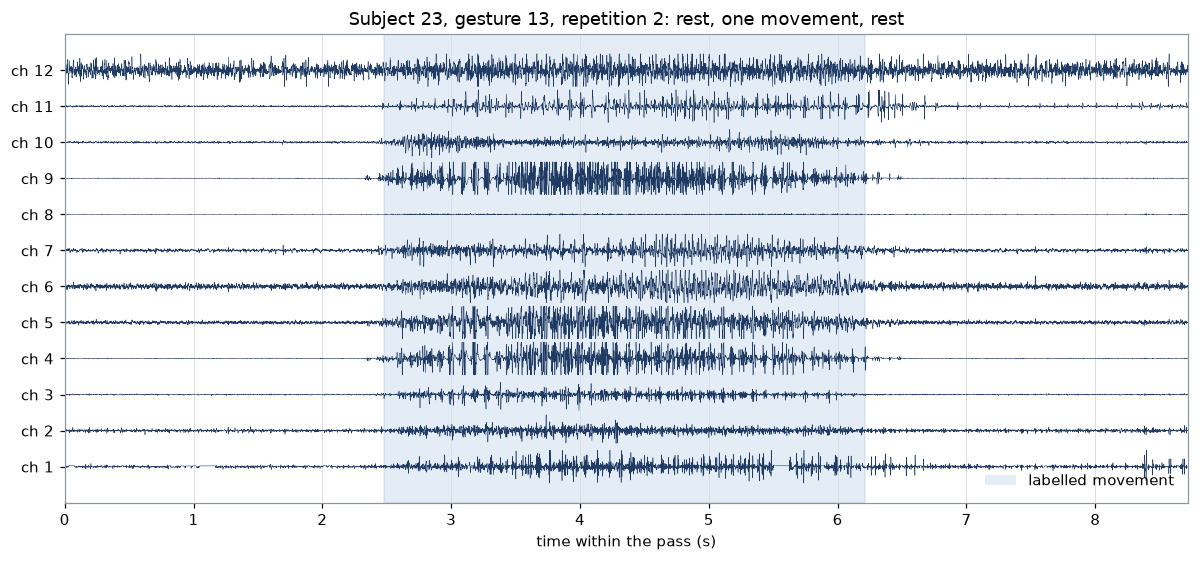

In [5]:
def plot_segment_signal(stream, labels, gesture, repetition, discard_chunks):
    """Plot all 12 electrodes of one held-out pass with the labelled movement shaded.

    Args:
        stream: (T, 12) int16 samples of one pass.
        labels: (n_steps,) per-step class ids for the scored part of the pass.
        gesture: the gesture id of this pass.
        repetition: the repetition id of this pass.
        discard_chunks: output steps dropped at the start of the pass, for the time axis.
    """
    seconds = np.arange(stream.shape[0]) / SAMPLE_RATE
    offset = 2.2 * np.abs(stream).max() / 32768.0
    normalised = stream / 32768.0

    figure, axes = plt.subplots(figsize=(11, 5.2))
    for channel in range(stream.shape[1]):
        axes.plot(seconds, normalised[:, channel] + channel * offset,
                  color=PALETTE["signal"], linewidth=0.35)

    discard_s = discard_chunks * CHUNK / SAMPLE_RATE
    step_seconds = discard_s + np.arange(labels.size) * STEP_MS / 1000.0
    moving = labels != REST
    if moving.any():
        axes.axvspan(step_seconds[moving][0], step_seconds[moving][-1],
                     color=PALETTE["movement"], alpha=0.13, zorder=0)

    axes.set_yticks([channel * offset for channel in range(stream.shape[1])])
    axes.set_yticklabels([f"ch {channel + 1}" for channel in range(stream.shape[1])])
    axes.set_xlabel("time within the pass (s)")
    axes.set_xlim(0, seconds[-1])
    axes.set_ylim(-offset, stream.shape[1] * offset)
    axes.grid(axis="y", visible=False)
    axes.set_title(f"Subject {SUBJECT}, gesture {gesture}, repetition {repetition}: "
                   f"rest, one movement, rest")
    axes.legend(handles=[Patch(facecolor=PALETTE["movement"], alpha=0.13,
                               label="labelled movement")],
                loc="lower right", ncol=1)
    figure.tight_layout()
    plt.show()


example = 24
plot_segment_signal(test["streams"][example], test["labels"][example],
                    test["gesture"][example], test["repetition"][example],
                    test["discard_chunks"])


### Figure: what the scored population actually contains

Rest is not a small corner case. Across the held-out passes it is roughly a third of every decision
the model has to make, and the 49 gestures are close to balanced with each other. A model that
simply never said "rest" would be wrong on a third of the stream and would keep the rest of the
system awake all day.


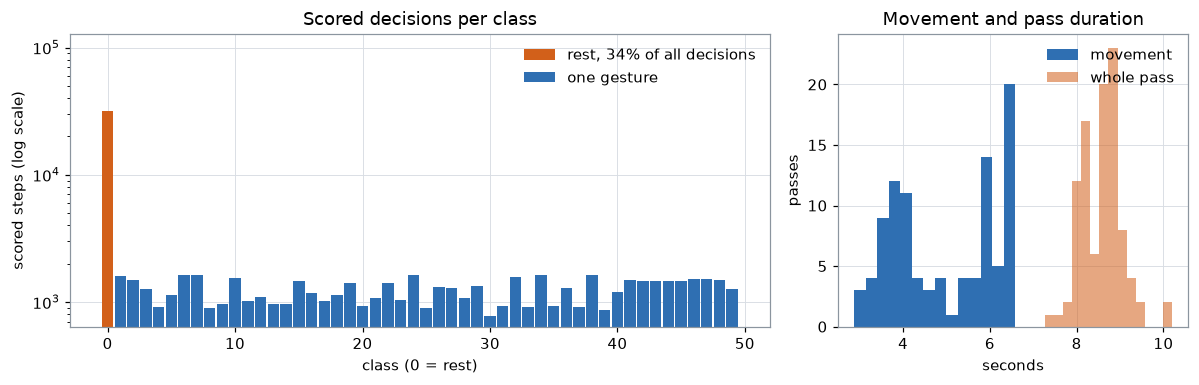

In [6]:
def plot_class_balance(labels_per_pass, streams):
    """Plot the share of scored steps per class and the distribution of movement durations.

    Args:
        labels_per_pass: list of (n_steps,) per-step label arrays, one per pass.
        streams: list of (T, 12) passes, used for their total duration.
    """
    labels = np.concatenate(labels_per_pass)
    counts = np.bincount(labels, minlength=NUM_CLASSES)
    durations = [float((one != REST).sum()) * STEP_MS / 1000.0 for one in labels_per_pass]
    pass_lengths = [stream.shape[0] / SAMPLE_RATE for stream in streams]

    figure, (left, right) = plt.subplots(1, 2, figsize=(11, 3.6),
                                         gridspec_kw={"width_ratios": [2, 1]})
    left.bar([0], [counts[REST]], color=PALETTE["accent"], width=0.9,
             label=f"rest, {counts[REST] / counts.sum():.0%} of all decisions")
    left.bar(np.arange(1, NUM_CLASSES), counts[1:], color=PALETTE["movement"], width=0.9,
             label="one gesture")
    left.set_yscale("log")
    left.set_xlabel("class (0 = rest)")
    left.set_ylabel("scored steps (log scale)")
    left.set_title("Scored decisions per class")
    left.set_ylim(top=counts.max() * 4)
    left.legend(loc="upper right")

    right.hist(durations, bins=14, color=PALETTE["movement"], label="movement")
    right.hist(pass_lengths, bins=14, color=PALETTE["accent"], alpha=0.55, label="whole pass")
    right.set_xlabel("seconds")
    right.set_ylabel("passes")
    right.set_title("Movement and pass duration")
    right.legend(loc="upper right")
    figure.tight_layout()
    plt.show()


plot_class_balance(test["labels"], test["streams"])


## 4. Forty subjects, forty models

Every number in this notebook, and every published number it is compared against, comes from
**one model trained per subject**, with the 40 per-subject accuracies then averaged.

The practical consequence, which belongs in any product conversation: **this task presupposes a
short per-user calibration step**, in which the user performs the gesture set a few times and a
model is fitted to them. Every result below, ours and everyone else's, is a subject-dependent
result. The protocol comes from the dataset paper (Atzori et al., 2014) and the whole field
follows it: **train on repetitions 1, 3, 4 and 6, test on repetitions 2 and 5**.

One neutral note on how the cohort number was produced: for each subject we report the better of
two independent training runs.


## 5. How the model is trained and how it is scored

This is the part that differs most from the published benchmarks, so it is worth a figure.

**The recording.** Each gesture's six repetitions are laid out one after another, each one about 5 s
of movement wrapped in rest. We cut the recording into **segments**, one per repetition, where each
segment is half the preceding rest, the movement, and half the following rest. The segments tile the
recording exactly, with no gap and no overlap, so every segment carries both of its own transitions:
the onset it begins with and the release it ends with.

**Training.** Repetitions 1, 3, 4 and 6 are for training. Adjacent training segments are fused into
**runs**, and a training crop must sit entirely inside one run. Because the segments tile, a crop
inside a run can only touch that run's own segments, which is what guarantees that no sample of a
held-out repetition ever reaches training. For this subject the crop is 8,208 samples, about 4.1 s,
and the model is supervised at **every one of its output steps**, not once per crop.

**Scoring.** Repetitions 2 and 5 are held out. Each held-out segment is streamed as **one
independent pass from a reset state**: clear the recurrent state, feed the segment chunk by chunk,
discard the first second of outputs while the state charges, then score every 8 ms step to the end
of the segment. That is 98 passes per subject, 49 gestures times 2 repetitions.

Two details in that protocol matter. The state is reset per segment rather than streamed across the
whole recording, because DB2's acquisition order is the same for every subject, so a continuous pass
would enter a held-out repetition carrying state built on the memorised training repetitions. And
every step is scored, including the onset ramp, not just a comfortable window from the middle.


In [7]:
def gesture_bursts(restimulus, rerepetition):
    """Find contiguous movement bursts in a label track.

    Args:
        restimulus: (T,) realigned label track, 0 for rest.
        rerepetition: (T,) repetition index track.

    Returns:
        List of (start, stop, gesture, repetition) with stop exclusive, in time order.
    """
    active = (np.asarray(restimulus) > 0).astype(np.int8)
    edges = np.diff(np.concatenate([[0], active, [0]]))
    starts, stops = np.flatnonzero(edges == 1), np.flatnonzero(edges == -1)
    return [
        (int(a), int(b), int(restimulus[a]), int(rerepetition[a]))
        for a, b in zip(starts, stops)
    ]


def repetition_segments(restimulus, rerepetition, lead_ms=4000.0, tail_ms=2000.0):
    """Cut the recording into one tiling segment per repetition.

    The rest between two consecutive movements is split at its midpoint, so consecutive segments
    share a boundary and together cover the recording without overlap.

    Args:
        restimulus: (T,) realigned label track.
        rerepetition: (T,) repetition index track.
        lead_ms: rest kept before the first movement, which has no predecessor to split with.
        tail_ms: rest kept after the last movement, for the same reason.

    Returns:
        List of dicts with lo, hi, onset, offset, gesture and repetition.
    """
    bursts = gesture_bursts(restimulus, rerepetition)
    total = int(np.asarray(restimulus).size)
    lead = int(round(lead_ms / 1000.0 * SAMPLE_RATE))
    tail = int(round(tail_ms / 1000.0 * SAMPLE_RATE))

    segments = []
    for index, (onset, offset, gesture, repetition) in enumerate(bursts):
        lo = max(0, onset - lead) if index == 0 else (bursts[index - 1][1] + onset) // 2
        hi = (min(total, offset + tail) if index == len(bursts) - 1
              else (offset + bursts[index + 1][0]) // 2)
        segments.append({"lo": lo, "hi": hi, "onset": onset, "offset": offset,
                         "gesture": gesture, "repetition": repetition})
    return segments


def fuse_runs(segments, repetitions):
    """Fuse adjacent segments belonging to the given repetitions into training runs.

    Args:
        segments: output of repetition_segments, in time order.
        repetitions: the repetition ids that belong to this split.

    Returns:
        List of dicts with lo, hi and the member segments.
    """
    keep = set(repetitions)
    runs = []
    for segment in segments:
        if segment["repetition"] not in keep:
            continue
        if runs and runs[-1]["hi"] == segment["lo"]:
            runs[-1]["hi"] = segment["hi"]
            runs[-1]["members"].append(segment)
        else:
            runs.append({"lo": segment["lo"], "hi": segment["hi"], "members": [segment]})
    return runs


excerpt = np.load(os.path.join(BASE_DIR, "test_data", "db2_s23_protocol_excerpt.npz"))
segments = repetition_segments(excerpt["restimulus"], excerpt["rerepetition"])
train_runs = fuse_runs(segments, (1, 3, 4, 6))

print(f"excerpt: {excerpt['emg'].shape[0] / SAMPLE_RATE:.1f} s of continuous recording, "
      f"{len(segments)} repetition segments")
for run in train_runs:
    members = ", ".join(f"g{m['gesture']} r{m['repetition']}" for m in run["members"])
    print(f"  training run {(run['hi'] - run['lo']) / SAMPLE_RATE:6.1f} s  [{members}]")


excerpt: 107.4 s of continuous recording, 12 repetition segments
  training run   11.3 s  [g1 r1]
  training run   17.7 s  [g1 r3, g1 r4]
  training run   17.4 s  [g1 r6, g2 r1]
  training run   17.5 s  [g2 r3, g2 r4]
  training run    8.4 s  [g2 r6]


### Figure: the protocol, end to end

Panel 1 is the real recording with its segment boundaries. Panel 2 shows which segments fuse into
training runs, and where a crop can sit. Panel 3 shows the held-out passes, each a cold start
with its first second discarded.


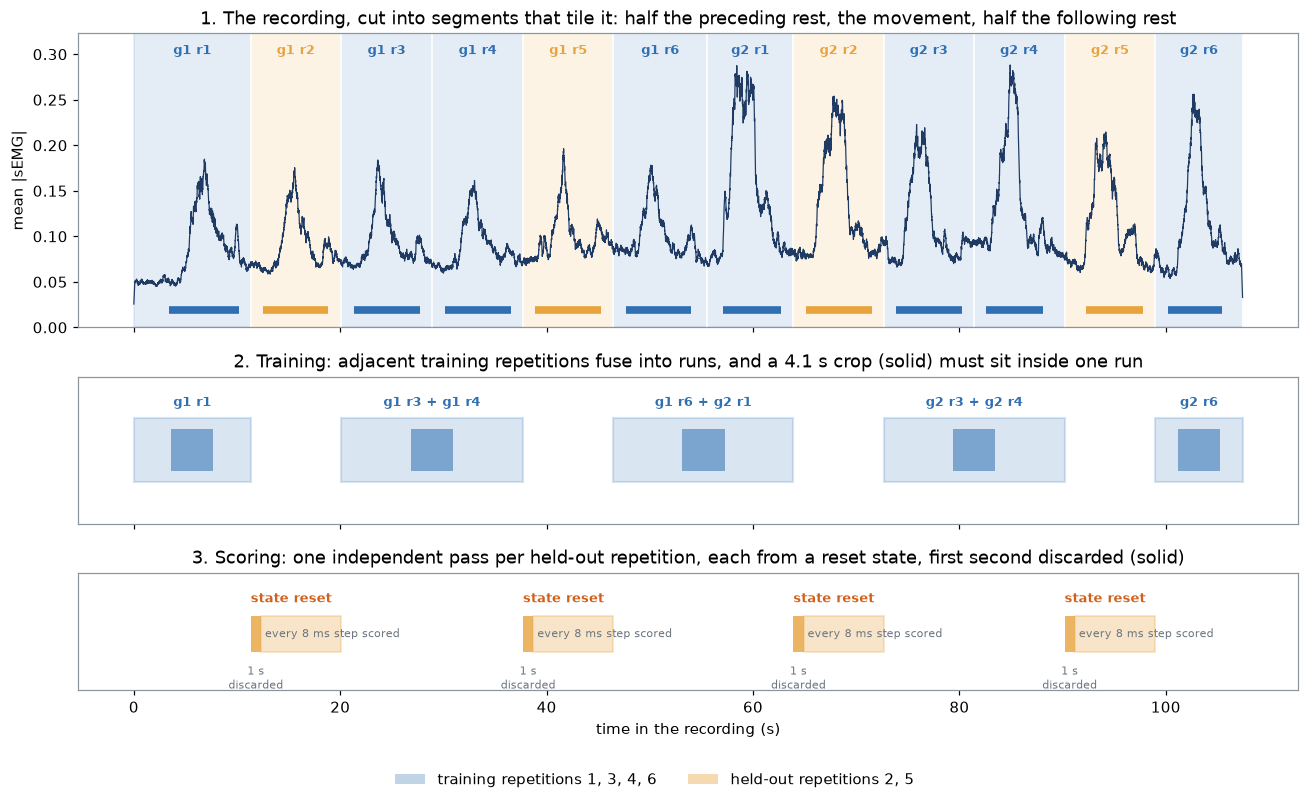

In [8]:
def plot_protocol(excerpt, segments, train_runs, test_reps=(2, 5), crop_length=TRAIN_LENGTH):
    """Draw the three stages of the protocol over one stretch of real recording.

    Args:
        excerpt: the shipped contiguous excerpt, with emg and both label tracks.
        segments: repetition segments covering the excerpt.
        train_runs: fused training runs over the same segments.
        test_reps: repetitions held out for scoring.
        crop_length: training crop length in input samples.
    """
    envelope = np.abs(excerpt["emg"].astype(np.float32)).mean(axis=1) / 32768.0
    smooth = np.convolve(envelope, np.ones(400) / 400, mode="same")
    seconds = np.arange(smooth.size) / SAMPLE_RATE

    figure, axes = plt.subplots(3, 1, figsize=(12, 7.2), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1.5, 1.2]})

    axes[0].plot(seconds, smooth, color=PALETTE["signal"], linewidth=0.8)
    top = smooth.max() * 1.12
    for segment in segments:
        held_out = segment["repetition"] in test_reps
        colour = PALETTE["test"] if held_out else PALETTE["movement"]
        axes[0].axvspan(segment["lo"] / SAMPLE_RATE, segment["hi"] / SAMPLE_RATE,
                        color=colour, alpha=0.13, zorder=0)
        axes[0].axvline(segment["hi"] / SAMPLE_RATE, color="white", linewidth=1.2, zorder=1)
        axes[0].plot([segment["onset"] / SAMPLE_RATE, segment["offset"] / SAMPLE_RATE],
                     [top * 0.06, top * 0.06], color=colour, linewidth=5, solid_capstyle="butt")
        axes[0].text((segment["lo"] + segment["hi"]) / 2 / SAMPLE_RATE, top * 0.93,
                     f"g{segment['gesture']} r{segment['repetition']}", ha="center",
                     fontsize=8.5, color=colour, fontweight="bold")
    axes[0].set_ylim(0, top)
    axes[0].set_ylabel("mean |sEMG|")
    axes[0].set_title("1. The recording, cut into segments that tile it: "
                      "half the preceding rest, the movement, half the following rest")
    axes[0].grid(visible=False)

    for run in train_runs:
        axes[1].add_patch(Rectangle((run["lo"] / SAMPLE_RATE, 0.28),
                                    (run["hi"] - run["lo"]) / SAMPLE_RATE, 0.44,
                                    facecolor=PALETTE["movement"], alpha=0.18,
                                    edgecolor=PALETTE["movement"], linewidth=1.4))
        members = " + ".join(f"g{m['gesture']} r{m['repetition']}" for m in run["members"])
        axes[1].text((run["lo"] + run["hi"]) / 2 / SAMPLE_RATE, 0.80, members,
                     ha="center", fontsize=8.5, color=PALETTE["movement"], fontweight="bold")
        if (run["hi"] - run["lo"]) >= crop_length:
            crop_start = (run["lo"] + run["hi"] - crop_length) / 2 / SAMPLE_RATE
            axes[1].add_patch(Rectangle((crop_start, 0.36), crop_length / SAMPLE_RATE, 0.28,
                                        facecolor=PALETTE["movement"], alpha=0.55,
                                        edgecolor="none"))
    axes[1].set_ylim(0, 1)
    axes[1].set_yticks([])
    axes[1].set_title(f"2. Training: adjacent training repetitions fuse into runs, and a "
                      f"{crop_length / SAMPLE_RATE:.1f} s crop (solid) must sit inside one run")
    axes[1].grid(visible=False)

    discard_s = 1.0
    for segment in segments:
        if segment["repetition"] not in test_reps:
            continue
        start, stop = segment["lo"] / SAMPLE_RATE, segment["hi"] / SAMPLE_RATE
        axes[2].add_patch(Rectangle((start, 0.22), discard_s, 0.36,
                                    facecolor=PALETTE["test"], alpha=0.8, edgecolor="none"))
        axes[2].add_patch(Rectangle((start + discard_s, 0.22), stop - start - discard_s, 0.36,
                                    facecolor=PALETTE["test"], alpha=0.28,
                                    edgecolor=PALETTE["test"], linewidth=1.2))
        axes[2].text(start, 0.68, "state reset", ha="left", va="bottom", fontsize=8.5,
                     color=PALETTE["accent"], fontweight="bold")
        axes[2].text(start + discard_s / 2, 0.10, f"{discard_s:.0f} s\ndiscarded", ha="center",
                     va="top", fontsize=7.5, color="#6b7580")
        axes[2].text(start + discard_s, 0.40, " every 8 ms step scored", ha="left",
                     va="center", fontsize=7.5, color="#6b7580")
    axes[2].set_ylim(-0.15, 1)
    axes[2].set_yticks([])
    axes[2].set_xlabel("time in the recording (s)")
    axes[2].set_title("3. Scoring: one independent pass per held-out repetition, each from a "
                      "reset state, first second discarded (solid)")
    axes[2].grid(visible=False)

    figure.legend(handles=[
        Patch(facecolor=PALETTE["movement"], alpha=0.3, label="training repetitions 1, 3, 4, 6"),
        Patch(facecolor=PALETTE["test"], alpha=0.4, label="held-out repetitions 2, 5"),
    ], loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.02))
    figure.tight_layout(rect=(0, 0.04, 1, 1))
    plt.show()


plot_protocol(excerpt, segments, train_runs)


## 6. Why a state space model rather than a transformer

The published DB2 models, TraHGR among them, are transformers or CNNs over a fixed window. That
shape carries two costs that matter for an always-on device, and neither is about accuracy.

**A window has to be buffered.** A 200 ms window at 2 kHz over 12 channels is 4,800 int16 values,
9.6 kB of RAM that has to exist before inference can start. A sliding window also re-reads each
sample once per window it belongs to, so the arithmetic is repeated as often as the windows
overlap.

**A window is also a ceiling on context.** Nothing older than 200 ms can influence the answer, no
matter how informative it is. TraHGR and the other published models classify one 200 ms window in
isolation: whatever happened before it simply is not available to them. TENNs-R has no such
ceiling. The state it carries into any given step summarises the whole pass so far, so a decision
can depend on something that happened well before the current moment, and nothing has to be
re-read for that to be true.

**TENNs-R turns the same computation into a recurrence.** Each state space layer keeps a small
complex state vector that is updated once per sample and then thrown forward. The deployed model
carries **7 layers times 64 states times 2 (real and imaginary) = 896 values at 16 bits, which is
1,792 bytes**, and that is the whole memory of the past. It does not grow with the length of the
stream. Each sample is read exactly once, and the input buffer is one 8 ms chunk, 384 bytes at
12 channels.


## 7. Build the model

TENNs-R is a stack of **kernelized state space blocks**. Each block is an S4D state space model with
diagonal complex poles, parameterised by `(A, B, C, log_dt)`: `B` projects the input into a state of
width `S`, `A` says how each state decays and rotates per sample, and `C` projects the state back
out to the block's output channels.

`akida_models.layer_blocks.kernelized_block` gives one block as
`Kernelized -> Stride -> BatchNormalization -> ReLU`. Everything below is the arrangement of those
blocks, and each choice is there for a reason:

| Choice | Value | Why |
|---|---|---|
| Blocks | 6, widening 16, 32, 64, 128, 192, 256 | narrow early where the timestep rate is highest, wide later where it is lowest |
| Head | a seventh block, 50 outputs, no batch norm, no activation | raw per-timestep logits for 49 gestures plus rest |
| State width `S` | 64, from `num_coeffs` 32 times `repeat` 2 | must be a power of two and identical in every layer for Pico; `repeat` splits the state into bands with different time constants |
| Subsampling | 2, 2, 2, 2, 1, 1, product 16 | decimates 2 kHz input to one decision every 16 samples, so 8 ms |
| Activation | unbounded `ReLU` | Pico rejects a capped ReLU |
| Input | int16, rescaled by 1/32768 | the device consumes int16 directly, with no filter bank or transform in front of it |
| No global pooling | | the model is supervised at every output step, because a continuous stream needs a label at every step, not one per clip |

Note what is **not** in the front end: no FFT, no spectrogram, no filter bank, no hand-designed
features. The model reads the raw sampled waveform.


In [9]:
def build_tenns_r(input_length, num_channels, num_classes,
                  channels=(16, 32, 64, 128, 192, 256), subsampling=(2, 2, 2, 2, 1, 1),
                  num_coeffs=32, repeat=2, dropout=0.1):
    """Build the conv-mode TENNs-R model that emits logits at every output timestep.

    Args:
        input_length: crop length in input samples. It must stay divisible by the running
            subsampling product, and it disappears at export: the deployed recurrence has no window.
        num_channels: input channels.
        num_classes: output channels of the head.
        channels: output channels per block.
        subsampling: temporal decimation per block. The product is the output cadence in samples.
        num_coeffs: state space coefficients per block; times repeat this is the state width.
        repeat: how many times the coefficients are repeated into timescale bands.
        dropout: SpatialDropout1D rate after each block.

    Returns:
        A Keras model mapping (batch, input_length, num_channels) int16 to
        (batch, input_length // prod(subsampling), num_classes) logits.
    """
    inputs = Input(shape=(input_length, num_channels), dtype=tf.int16, name="input")
    features = Rescaling(1.0 / 2**15, 0.0, name="rescaling")(inputs)

    for index, (width, stride) in enumerate(zip(channels, subsampling)):
        features = kernelized_block(
            features,
            num_coeffs,
            width,
            subsampling=(stride if stride > 1 else None),
            add_batchnorm=True,
            relu_activation="ReLU",
            repeat=repeat,
            name=f"ssm_layer_{index}",
        )
        features = SpatialDropout1D(dropout, name=f"ssm_layer_{index}/dropout")(features)

    logits = kernelized_block(
        features,
        num_coeffs,
        num_classes,
        subsampling=False,
        add_batchnorm=False,
        relu_activation=False,
        repeat=repeat,
        name="ssm_layer_head",
    )
    return Model(inputs, logits, name="tenn_recurrent")


model = build_tenns_r(TRAIN_LENGTH, NUM_CHANNELS, NUM_CLASSES)
model.summary()
print(f"\ntrainable parameters: {model.count_params():,}")
print(f"output steps per crop: {model.output_shape[1]} "
      f"(one every {CHUNK} input samples, {STEP_MS:.0f} ms apart)")


Model: "tenn_recurrent"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 input (InputLayer)          [(None, 8208, 12)]        0         


 rescaling (Rescaling)       (None, 8208, 12)          0         


...

Total params: 96128 (375.50 KB)


Trainable params: 94752 (370.12 KB)


Non-trainable params: 1376 (5.38 KB)


_________________________________________________________________



trainable parameters: 96,128
output steps per crop: 513 (one every 16 input samples, 8 ms apart)


## 8. Load the trained weights and convert to the streaming form

The shipped weights are subject 23's trained float model, from the run that produced that subject's
row in the 40-subject table at the end of this notebook.

**Why a conversion is needed at all.** During training the kernelized block materialises the state
space kernel over the whole crop and applies it as a convolution, so a GPU computes all 513 output
steps of a crop in parallel. That is the right shape for training and the wrong shape for a device,
which sees 16 new samples at a time and must answer immediately.

`convert_to_stateful` rewrites the same function as a running recurrence. Each `Kernelized` block
becomes `StatefulProjection -> StatefulRecurrent -> ExtractToken -> StatefulProjection`, the state
matrices are discretised with a zero-order hold (`A_hat = exp(dt * A)`), the `Stride` is folded into
the output projection, dropout is deleted and batch norm is folded into the projections' biases.

Two consequences worth dwelling on:

- **The window disappears.** `A_hat` does not contain the crop length. Once converted, the model has
  no notion of a window, a crop or a buffer; it is parameterised entirely by the learned per-state
  decay. The 8,208-sample training crop is a training-time construct only.
- **The interface becomes a stream.** Input `(1, 16, 12)`, output `(1, 1, 50)`: one 8 ms buffer in,
  one 50-way logit vector out, with the state carried across calls.

The two forms compute the same function, and the cell after the conversion checks that numerically
on real held-out signal rather than taking it on trust.


In [10]:
model.load_weights(os.path.join(BASE_DIR, "weights", "tenns_r_db2_s23.weights.h5"))

stateful = convert_to_stateful(model, CHUNK)

print(f"training graph : input {model.input_shape}, output {model.output_shape}, "
      f"{model.count_params():,} parameters")
print(f"deployed graph : input {stateful.input_shape}, output {stateful.output_shape}, "
      f"{stateful.count_params():,} parameters")
print("\nlayer types after conversion:")
counts = Counter(layer.__class__.__name__ for layer in stateful.layers)
for name, count in counts.most_common():
    print(f"  {name:<20} {count}")

recurrent = [layer for layer in stateful.layers
             if layer.__class__.__name__ == "StatefulRecurrent"]
state_values = sum(64 * 2 for _ in recurrent)
print(f"\n{len(recurrent)} recurrent layers x 64 states x 2 (real and imaginary) "
      f"= {state_values} values")
print(f"live state carried between calls: {state_values * 2:,} bytes at 16 bits, "
      f"constant however long the stream runs")


training graph : input (None, 8208, 12), output (None, 513, 50), 96,128 parameters
deployed graph : input (1, 16, 12), output (1, 1, 50), 93,616 parameters

layer types after conversion:
  StatefulProjection   14
  StatefulRecurrent    7
  ExtractToken         7
  ReLU                 6
  InputLayer           1
  Rescaling            1

7 recurrent layers x 64 states x 2 (real and imaginary) = 896 values
live state carried between calls: 1,792 bytes at 16 bits, constant however long the stream runs


In [11]:
def stream_passes(stateful_model, passes, discard_chunks, batch_size=None):
    """Stream each pass from a reset state and return its per-step logits.

    Passes in a batch are zero-padded to the longest so they advance in lockstep. Padding cannot
    contaminate a result because it sits after a pass has ended, and those outputs are dropped.

    Args:
        stateful_model: the converted model, float or quantized.
        passes: list of (T, C) int16 streams, each a whole number of chunks long.
        discard_chunks: leading output steps dropped from every pass, the cold start.
        batch_size: passes advanced concurrently. Defaults to all of them.

    Returns:
        List of (n_steps, num_classes) float arrays, one per pass, in input order.
    """
    batch_size = batch_size or len(passes)
    stateful_model = update_batch_size(stateful_model, batch_size)
    # Without tf.function every 8 ms chunk pays eager overhead, and a quantized recurrent chain is
    # expensive per call. The shapes are fixed, so it traces once.
    traced = tf.function(stateful_model, reduce_retracing=True)

    results = [None] * len(passes)
    order = sorted(range(len(passes)), key=lambda i: passes[i].shape[0])
    num_channels = passes[0].shape[1]

    for start in range(0, len(order), batch_size):
        group = order[start : start + batch_size]
        chunks_each = [passes[i].shape[0] // CHUNK for i in group]
        longest = max(chunks_each)
        batch = np.zeros((batch_size, longest * CHUNK, num_channels), dtype=np.int16)
        for slot, index in enumerate(group):
            batch[slot, : passes[index].shape[0]] = passes[index]

        reset_states(stateful_model)
        outputs = [np.asarray(traced(batch[:, at : at + CHUNK, :]))
                   for at in range(0, longest * CHUNK, CHUNK)]
        collected = np.concatenate(outputs, axis=1)
        for slot, index in enumerate(group):
            results[index] = collected[slot, discard_chunks : chunks_each[slot]]
    return results


crops = [stream[:TRAIN_LENGTH] for stream in test["streams"][:4]]
conv_logits = np.asarray(model(np.stack(crops), training=False))
stream_logits = np.stack(stream_passes(stateful, crops, discard_chunks=0, batch_size=len(crops)))

largest = float(np.abs(conv_logits - stream_logits).max())
agreement = float((conv_logits.argmax(-1) == stream_logits.argmax(-1)).mean())
print(f"conv mode vs streaming over {len(crops)} crops x {conv_logits.shape[1]} output steps")
print(f"  max absolute difference : {largest:.3e}")
print(f"  logit standard deviation: {conv_logits.std():.3e}")
print(f"  relative to that scale  : {largest / conv_logits.std():.3e}")
print(f"  argmax agreement        : {agreement * 100:.3f} %")


conv mode vs streaming over 4 crops x 513 output steps
  max absolute difference : 2.360e-05
  logit standard deviation: 1.542e+00
  relative to that scale  : 1.531e-05
  argmax agreement        : 100.000 %


## 9. Quantize to int8

The device runs integer arithmetic, so the deployed model is int8 weights, int8 activations and an
int16 input. Quantization is post-training: `quantizeml` pushes representative data through the
model and picks the scales that keep the integer values faithful to the float behaviour.

**Quantize the stateful model, not the training model.** The order is
`load weights -> convert to stateful -> quantize`, and it is not interchangeable. The stateful
graph is the one that will run, its discretised `A_hat` and folded batch norm are what the
activation ranges have to be fitted to, and quantizeml has no target for the training graph's
`Kernelized` layer. It is easy to assume the other order; it does not work.

**Calibration has to be streams, not windows.** `quantizeml` reads the calibration array as
`(n_streams, T, channels)`: axis 0 is independent streams and axis 1 is time, and it feeds
`T / 16` consecutive chunks per stream with the state carried. The shipped calibration is 98
streams of 5 s drawn from **training repetitions only**, each starting 1 s before a movement onset
so the state charges on rest and then walks the onset ramp, exactly as it will in deployment. If
you passed independent windows instead, every chunk would be seen from a zero state and the
activation ranges would be fitted to a post-reset transient the deployed model never sits in.


In [12]:
calibration = np.load(os.path.join(BASE_DIR, "calibration", "db2_s23_calibration.npz"))["streams"]
print(f"calibration: {calibration.shape[0]} streams x "
      f"{calibration.shape[1] / SAMPLE_RATE:.0f} s x {calibration.shape[2]} channels")
print(f"  = {calibration.shape[0] * calibration.shape[1] // CHUNK:,} chunk steps, "
      f"state carried within each stream")

started = time.time()
quantized = quantizeml.models.quantize(
    stateful,
    qparams=QuantizationParams(activation_bits=8, weight_bits=8, input_dtype="int16"),
    samples=calibration,
    batch_size=calibration.shape[0],
    epochs=1,
)
print(f"\nquantized in {time.time() - started:.0f} s")

projection_kernels = sum(
    int(np.prod(weight.shape)) for layer in quantized.layers
    if "StatefulProjection" in layer.__class__.__name__
    for weight in layer.weights if len(weight.shape) == 2
)
print(f"int8 projection kernels: {projection_kernels:,} weights, so {projection_kernels:,} bytes "
      f"({projection_kernels / 1024:.1f} KiB) at one byte each")
print("the projections are about 99 % of the deployed model; the recurrent matrices are the rest")


calibration: 98 streams x 5 s x 12 channels
  = 61,250 chunk steps, state carried within each stream



quantized in 24 s
int8 projection kernels: 92,032 weights, so 92,032 bytes (89.9 KiB) at one byte each
the projections are about 99 % of the deployed model; the recurrent matrices are the rest


## 10. Convert to Akida and check it against Akida Pico

`cnn2snn.convert` turns the quantized Keras model into a native Akida model. `model.map(device)`
then asks the mapper whether that model fits a given device. With `hw_only=True` there is no
partial credit and no silent fallback to software: either the whole chain runs on the device or the
mapping fails, and the failure names every constraint that was broken.

Akida Pico is a single TNP-R with no mesh. It accepts a strictly linear chain of `InputData`,
`Quantizer`, `StatefulRecurrent`, `PicoPostProcessing` and `Dequantizer`, and it has four separate
memories:

| Memory | Holds | Shipped Pico FPGA budget |
|---|---|---|
| STSRAM | the live recurrent state | 448 words of 32 bits |
| FSRAM | the projection weights | 8,192 words of 64 bits |
| TSRAM | per-layer configuration and tensor descriptors | 892 words of 51 bits |
| EVSRAM | events in flight between layers | 256 words of 32 bits |

`akida.PicoIP()` is a virtual device carrying exactly that configuration, so the check below is a
real gate and needs no hardware attached.

One thing to expect in the summary that `cnn2snn.convert` prints: with no Pico attached to this
machine the converted model reports a **Software** backend, because it has not been placed on a
device. That is separate from the question the mapper answers, which is whether it *could* be.


In [13]:
akida_model = cnn2snn.convert(quantized)
akida_model.summary()

print(f"\nMACs per 8 ms inference, as the mapper counts them: "
      f"{sum(layer.macs for layer in akida_model.layers):,}")
print("the compute this implies is worked through below, after the input row is padded")


                Model Summary                 
______________________________________________
Input shape  Output shape  Sequences  Layers
[1, 16, 12]  [1, 1, 50]    1          9     
______________________________________________

__________________________________________________________________________________________________
Layer (type)                                    Output shape  Kernel shape                      

======================== SW/ssm_layer_0_output_proj-dequantizer (Software) =======================

ssm_layer_0_output_proj (StatefulRecurrent)     [1, 8, 16]    (12, 64)  (64,)  (64,)  (64, 16)  
__________________________________________________________________________________________________
ssm_layer_1_output_proj (StatefulRecurrent)     [1, 4, 32]    (16, 64)  (64,)  (64,)  (64, 32)  
__________________________________________________________________________________________________
ssm_layer_2_output_proj (StatefulRecurrent)     [1, 2, 64]    (32, 64)  (64,)  

In [14]:
def map_to_pico(model_to_map, device, label):
    """Map a converted model onto a Pico device and report the outcome.

    Args:
        model_to_map: the model from cnn2snn.convert.
        device: the Akida device to map onto.
        label: a short name for this attempt, used in the printout.

    Returns:
        Dict of per-memory word occupancy when the mapping succeeds, otherwise None.
    """
    print(f"--- {label} ---")
    try:
        model_to_map.map(device, hw_only=True)
    except Exception as failure:
        print(f"REFUSED\n{failure}\n")
        return None
    occupancy = dict(zip(
        ("stsram_32b", "fsram_64b", "tsram_51b", "evsram_32b"),
        (int(words) for words in list(akida.compute_minimal_memory(model_to_map))[2:]),
    ))
    print(f"MAPPED, {len(model_to_map.sequences)} hardware sequence, occupancy {occupancy}\n")
    return occupancy


map_to_pico(akida_model, akida.PicoIP(), "as trained, 12 input channels, shipped Pico FPGA")


--- as trained, 12 input channels, shipped Pico FPGA ---
REFUSED
Cannot map layer 'ssm_layer_0_output_proj'. The packed input row (channels x input bits) must occupy a power-of-2 number of 32-bit words (got 6 words for 12 channels at 16-bit). FSRAM size exceeds max limit of 8192 64-bit words for TNP-R (got 11552). TSRAM size exceeds max limit of 892 51-bit words for TNP-R (got 1275).



### Reading the refusal

The mapper reports three separate problems, and they are different in kind.

1. **The packed input row must occupy a power-of-two number of 32-bit words.** Twelve channels at
   16 bits is six words, which is not a power of two; 16 channels is eight words, which is. This is
   a structural rule about how Pico packs an input row, not a capacity limit, and the fix is to pad
   the input to 16 channels and feed the four extra channels zeros. Padding costs nothing in
   accuracy, and the next cell shows why: the first projection's weights for the padded channels
   are zero, so the output is bit-identical.
2. **FSRAM overflows.** The projection weights need more than the 8,192 words the board has.
3. **TSRAM overflows.** The per-layer descriptors need more than the 892 words the board has.

Points 2 and 3 are capacity, and no rearrangement of this architecture fixes them. They are the
reason this model does not run on the shipped Pico FPGA today.

Let us deal with point 1 first, so the capacity numbers can be read on their own.


In [15]:
def pad_input_channels(source, num_channels):
    """Rebuild the model with a wider input and zero-pad the first projection's weights.

    The added channels are multiplied by zero, so the padded model computes exactly the same
    function as long as the extra channels are fed zeros.

    Args:
        source: the trained conv-mode model.
        num_channels: the wider input width, a power-of-two packed row for Pico.

    Returns:
        A conv-mode model with num_channels inputs and the same behaviour.
    """
    padded = build_tenns_r(source.input_shape[1], num_channels, NUM_CLASSES)
    for original, target in zip(source.weights, padded.weights):
        values = original.numpy()
        if values.shape != target.shape:
            widened = np.zeros(target.shape, dtype=values.dtype)
            widened[: values.shape[0]] = values
            values = widened
        target.assign(values)
    return padded


def pad_channels(streams, num_channels):
    """Zero-pad a batch of int16 streams up to the deploy channel count."""
    widened = np.zeros((*streams.shape[:-1], num_channels), dtype=streams.dtype)
    widened[..., : streams.shape[-1]] = streams
    return widened


padded_model = pad_input_channels(model, DEPLOY_CHANNELS)
check = np.stack(crops)
difference = float(np.abs(
    np.asarray(model(check, training=False))
    - np.asarray(padded_model(pad_channels(check, DEPLOY_CHANNELS), training=False))
).max())
print(f"12-channel and zero-padded 16-channel models differ by {difference:.1e} "
      f"on {check.shape[0]} held-out crops")
print(f"parameters: {model.count_params():,} at 12 channels, "
      f"{padded_model.count_params():,} at 16")


12-channel and zero-padded 16-channel models differ by 0.0e+00 on 4 held-out crops
parameters: 96,128 at 12 channels, 96,384 at 16


In [16]:
padded_stateful = convert_to_stateful(padded_model, CHUNK)
padded_quantized = quantizeml.models.quantize(
    padded_stateful,
    qparams=QuantizationParams(activation_bits=8, weight_bits=8, input_dtype="int16"),
    samples=pad_channels(calibration, DEPLOY_CHANNELS),
    batch_size=calibration.shape[0],
    epochs=1,
)
padded_akida = cnn2snn.convert(padded_quantized)
print(f"deploy-width model: input {padded_akida.input_shape}, "
      f"{sum(layer.macs for layer in padded_akida.layers):,} MACs per 8 ms inference")

FPGA_SRAM = {"stsram_32b": 448, "fsram_64b": 8192, "tsram_51b": 892, "evsram_32b": 256}


def pico_ip_device(stsram=1, fsram=1, tsram=1, evsram=1):
    """Build a virtual Pico IP whose four SRAMs are multiples of the FPGA board's.

    The Pico IP is synthesised with configurable SRAM, so a model that overflows the board can still
    be legal IP. The mapper remains the authority on whether a configuration actually covers it.

    Args:
        stsram: multiplier on the state memory.
        fsram: multiplier on the weight memory.
        tsram: multiplier on the descriptor memory.
        evsram: multiplier on the event memory.

    Returns:
        An akida.Device with the scaled memory configuration.
    """
    size = akida.NP.SramSize(
        FPGA_SRAM["stsram_32b"] * stsram,
        FPGA_SRAM["fsram_64b"] * fsram,
        FPGA_SRAM["tsram_51b"] * tsram,
        FPGA_SRAM["evsram_32b"] * evsram,
    )
    # include_hrc=False matters: create_device defaults it to True, and no real Pico has an HRC.
    return akida.create_device(1, 0, include_hrc=False, hw_version=akida.Pico_FPGA,
                               sram_size=size)


map_to_pico(padded_akida, akida.PicoIP(), "16 input channels, shipped Pico FPGA")
map_to_pico(padded_akida, pico_ip_device(fsram=2), "Pico IP with 2x FSRAM only")
map_to_pico(padded_akida, pico_ip_device(tsram=2), "Pico IP with 2x TSRAM only")
map_to_pico(padded_akida, pico_ip_device(fsram=2, tsram=2), "Pico IP with 2x FSRAM and 2x TSRAM")


deploy-width model: input [1, 16, 16], 150,912 MACs per 8 ms inference
--- 16 input channels, shipped Pico FPGA ---
REFUSED
Cannot map layer 'ssm_layer_0_output_proj'. FSRAM size exceeds max limit of 8192 64-bit words for TNP-R (got 11584). TSRAM size exceeds max limit of 892 51-bit words for TNP-R (got 1276).

--- Pico IP with 2x FSRAM only ---
REFUSED
Cannot map layer 'ssm_layer_0_output_proj'. TSRAM size exceeds max limit of 892 51-bit words for TNP-R (got 1276).

--- Pico IP with 2x TSRAM only ---
REFUSED
Cannot map layer 'ssm_layer_0_output_proj'. FSRAM size exceeds max limit of 8192 64-bit words for TNP-R (got 11584).

--- Pico IP with 2x FSRAM and 2x TSRAM ---
MAPPED, 1 hardware sequence, occupancy {'stsram_32b': 448, 'fsram_64b': 11584, 'tsram_51b': 1276, 'evsram_32b': 188}



{'stsram_32b': 448, 'fsram_64b': 11584, 'tsram_51b': 1276, 'evsram_32b': 188}

### What this means for a Pico deployment

A **Pico IP synthesised with twice the FSRAM and twice the TSRAM** accommodates this model. The
cells above show it directly: doubling either memory on its own is still refused, and doubling both
maps the whole chain as a single hardware sequence. The Pico IP's memories are chosen at synthesis
time, so this is a configuration statement rather than a barrier.

**No performance claim is made here.** This model has never run on Akida silicon or on the Pico
FPGA, so this notebook reports no frames per second, no latency, no power and no energy.

## 11. Streaming inference on held-out data

Now run the int8 model the way a device would: reset the state, feed 16 samples at a time, take one
50-way logit vector per call, and never look at anything but the past.

Every held-out pass of subject 23 is streamed below. Passes are advanced in a batch only to use the
CPU efficiently; each one keeps its own state and its own reset, so batching changes the wall clock
and nothing else.


In [17]:
started = time.time()
int8_logits = stream_passes(quantized, test["streams"], test["discard_chunks"])
elapsed = time.time() - started

emitted = sum(logits.shape[0] for logits in int8_logits)
print(f"streamed {len(test['streams'])} passes, {emitted:,} decisions, in {elapsed:.0f} s")
print(f"that is {emitted * STEP_MS / 1000.0 / 60:.1f} minutes of signal at the 8 ms cadence")


streamed 98 passes, 92,918 decisions, in 47 s
that is 12.4 minutes of signal at the 8 ms cadence


In [18]:
def score_steps(logits, labels):
    """Score per-step logits with both the 49-class and 50-class decision rules.

    The 50-way argmax is what the device emits. The 49-way rule deletes the rest logit so rest can
    never be the answer, which is the rule the published DB2 results use, since their models have no
    rest class at all.

    Args:
        logits: (n_steps, 50) concatenated over every pass, cold starts already dropped.
        labels: (n_steps,) per-step class ids.

    Returns:
        Dict with acc_49, acc_50, rest_fp_rate and the step counts behind them.
    """
    moving = labels != REST
    predicted_50 = logits.argmax(axis=1)
    gesture_ids = np.delete(np.arange(NUM_CLASSES), REST)
    predicted_49 = gesture_ids[np.delete(logits, REST, axis=1).argmax(axis=1)]

    return {
        "acc_49": float((predicted_49[moving] == labels[moving]).mean()),
        "acc_50": float((predicted_50[moving] == labels[moving]).mean()),
        "rest_fp_rate": float((predicted_50[~moving] != REST).mean()),
        "n_gesture_steps": int(moving.sum()),
        "n_rest_steps": int((~moving).sum()),
    }


labels = np.concatenate(test["labels"])
int8_scores = score_steps(np.concatenate(int8_logits), labels)

print(f"subject {SUBJECT}, int8, {labels.size:,} scored decisions")
print(f"  acc_49       {int8_scores['acc_49'] * 100:6.2f} %   "
      f"gesture steps only, rest deleted from the argmax, over "
      f"{int8_scores['n_gesture_steps']:,} steps")
print(f"  acc_50       {int8_scores['acc_50'] * 100:6.2f} %   "
      f"same steps, but the model may also answer 'rest'")
print(f"  rest_fp_rate {int8_scores['rest_fp_rate'] * 100:6.2f} %   "
      f"of the {int8_scores['n_rest_steps']:,} rest steps name a gesture")


subject 23, int8, 92,918 scored decisions
  acc_49        86.82 %   gesture steps only, rest deleted from the argmax, over 61,059 steps
  acc_50        82.41 %   same steps, but the model may also answer 'rest'
  rest_fp_rate  19.44 %   of the 31,859 rest steps name a gesture


In [19]:
started = time.time()
float_logits = stream_passes(stateful, test["streams"], test["discard_chunks"])
float_scores = score_steps(np.concatenate(float_logits), labels)
print(f"float pass streamed in {time.time() - started:.0f} s")
print(f"  float acc_49 {float_scores['acc_49'] * 100:.2f} %")
print(f"  int8  acc_49 {int8_scores['acc_49'] * 100:.2f} %")
print(f"  quantization costs {(float_scores['acc_49'] - int8_scores['acc_49']) * 100:.2f} "
      f"points on this subject")


float pass streamed in 19 s
  float acc_49 86.85 %
  int8  acc_49 86.82 %
  quantization costs 0.03 points on this subject


### Figure: per-step predictions against ground truth

One held-out pass, decision by decision. The shaded band is the true movement. The dots are the
model's 50-way answer at each 8 ms step, blue where it matches the truth and orange where it does
not. Notice where the errors cluster: at the onset ramp, and at the release, which are exactly the
transitions a window-based benchmark never scores.


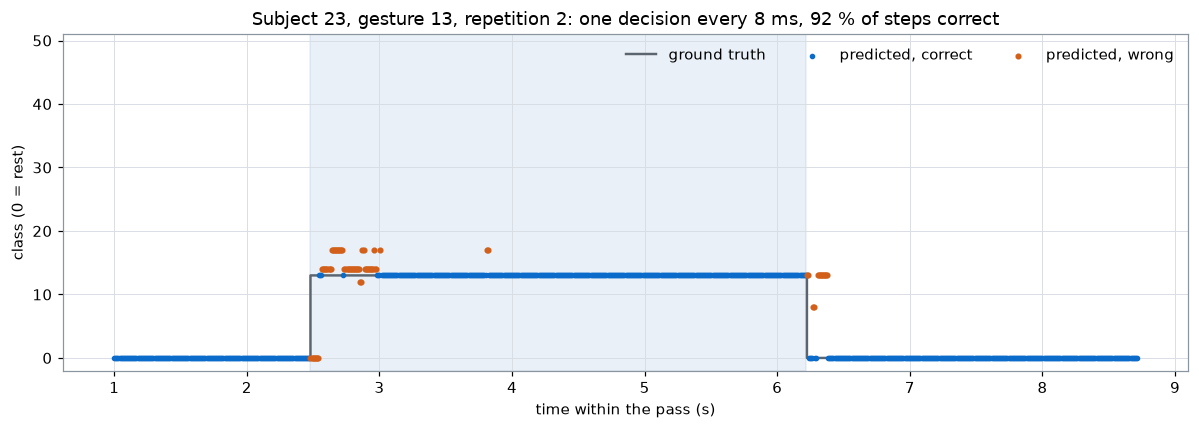

In [20]:
def plot_step_predictions(logits, labels, gesture, repetition, discard_chunks):
    """Plot the 50-way prediction at every 8 ms step of one pass against the truth.

    Args:
        logits: (n_steps, 50) logits for this pass.
        labels: (n_steps,) true class per step.
        gesture: the pass's gesture id.
        repetition: the pass's repetition id.
        discard_chunks: steps dropped at the start of the pass, for the time axis.
    """
    predicted = logits.argmax(axis=1)
    seconds = (discard_chunks + np.arange(labels.size)) * STEP_MS / 1000.0
    correct = predicted == labels
    moving = labels != REST

    figure, axes = plt.subplots(figsize=(11, 4))
    if moving.any():
        axes.axvspan(seconds[moving][0], seconds[moving][-1],
                     color=PALETTE["movement"], alpha=0.10, zorder=0)
    axes.step(seconds, labels, where="post", color="#5a6570", linewidth=1.6,
              label="ground truth", zorder=1)
    axes.scatter(seconds[correct], predicted[correct], s=7, color=PALETTE["ours"],
                 label="predicted, correct", zorder=2)
    axes.scatter(seconds[~correct], predicted[~correct], s=9, color=PALETTE["accent"],
                 label="predicted, wrong", zorder=3)
    axes.set_xlabel("time within the pass (s)")
    axes.set_ylabel("class (0 = rest)")
    axes.set_ylim(-2, NUM_CLASSES + 1)
    axes.set_title(f"Subject {SUBJECT}, gesture {gesture}, repetition {repetition}: "
                   f"one decision every {STEP_MS:.0f} ms, "
                   f"{correct.mean() * 100:.0f} % of steps correct")
    axes.legend(loc="upper right", ncol=3)
    figure.tight_layout()
    plt.show()


plot_step_predictions(int8_logits[example], test["labels"][example],
                      test["gesture"][example], test["repetition"][example],
                      test["discard_chunks"])


## 12. The trigger: deciding that something is happening at all

The classifier answers "which gesture". A product also needs "is anything happening", and it needs
that answer cheaply, because it is what lets everything downstream stay powered down.

The model already carries the answer. It has a rest class, so

$$P(\text{gesture}) = 1 - \text{softmax}(\text{logits})[\,\text{rest}\,]$$

is a continuous confidence that the hand is moving, available at every 8 ms step for no extra
compute. Turning that into a usable wake signal takes three standard pieces:

- a **threshold**, chosen from held-out rest steps to hit a target false-alarm rate,
- a **debounce**, requiring a few consecutive steps above the threshold before asserting, which
  removes single-step spikes,
- a **hold**, keeping the downstream system awake for a while after the signal drops, so a brief
  dip does not power-cycle it.

The threshold is picked **per subject**, from that subject's own rest steps. That is the same
assumption the accuracy numbers already make: a product built on this needs a short per-user
calibration, and the threshold is fitted in the same step.


In [21]:
def gesture_probability(logits):
    """Return P(any gesture) = 1 - softmax(logits)[rest], computed stably in float64.

    Args:
        logits: (n_steps, num_classes) per-step logits.

    Returns:
        (n_steps,) probability that the hand is moving.
    """
    shifted = np.asarray(logits, dtype=np.float64)
    shifted = shifted - shifted.max(axis=1, keepdims=True)
    exponentiated = np.exp(shifted)
    return 1.0 - exponentiated[:, REST] / exponentiated.sum(axis=1)


def debounced_state(above, debounce_steps):
    """Assert only after the score has stayed above the threshold for several steps.

    Args:
        above: (n_steps,) boolean, whether the score cleared the threshold.
        debounce_steps: consecutive steps required before the trigger asserts.

    Returns:
        (n_steps,) boolean trigger state.
    """
    needed = max(int(debounce_steps), 1)
    indices = np.arange(above.size)
    last_low = np.maximum.accumulate(np.where(~above, indices, -1))
    return above & ((indices - last_low) >= needed)


def with_hold(state, hold_steps):
    """Extend an asserted trigger forward, so a brief dip does not drop the downstream system.

    Args:
        state: (n_steps,) boolean trigger state.
        hold_steps: steps to stay awake after the trigger last asserted.

    Returns:
        (n_steps,) boolean awake state.
    """
    if hold_steps <= 0:
        return state
    indices = np.arange(state.size)
    last_high = np.maximum.accumulate(np.where(state, indices, -1))
    return state | ((last_high >= 0) & ((indices - last_high) <= hold_steps))


def detection_latency_ms(state, labels):
    """Milliseconds from the true movement onset to the trigger asserting inside that movement.

    Args:
        state: (n_steps,) boolean trigger state for one pass.
        labels: (n_steps,) true class per step for the same pass.

    Returns:
        Latency in ms, or nan when the trigger never asserts during the movement.
    """
    moving = np.flatnonzero(labels != REST)
    if moving.size == 0:
        return float("nan")
    first, last = moving[0], moving[-1]
    asserted = np.flatnonzero(state[first : last + 1])
    return float(asserted[0]) * STEP_MS if asserted.size else float("nan")


TARGET_FALSE_ALARM_RATE = 0.05
DEBOUNCE_STEPS = 3                                  # 24 ms
HOLD_STEPS = int(round(500.0 / STEP_MS))            # 62 steps, just under 500 ms

probabilities = [gesture_probability(logits) for logits in int8_logits]
rest_scores = np.concatenate([
    probability[pass_labels == REST]
    for probability, pass_labels in zip(probabilities, test["labels"])
])
threshold = float(np.quantile(rest_scores, 1.0 - TARGET_FALSE_ALARM_RATE))
print(f"threshold at a {TARGET_FALSE_ALARM_RATE:.0%} false-alarm rate on rest steps: "
      f"{threshold:.3f}")


threshold at a 5% false-alarm rate on rest steps: 0.954


In [22]:
def summarise_trigger(probabilities, labels_per_pass, threshold, debounce_steps, hold_steps):
    """Apply the trigger to every pass and summarise latency, misses and duty cycle.

    Args:
        probabilities: list of (n_steps,) P(gesture) arrays, one per pass.
        labels_per_pass: list of (n_steps,) true class arrays, one per pass.
        threshold: P(gesture) at which the trigger fires.
        debounce_steps: consecutive steps required before asserting.
        hold_steps: steps kept awake after the trigger last asserted.

    Returns:
        Dict with the per-pass latencies, the miss count and the awake fraction.
    """
    latencies, awake_steps, total_steps, misses = [], 0, 0, 0
    awake_rest_steps, rest_steps = 0, 0
    for probability, pass_labels in zip(probabilities, labels_per_pass):
        state = debounced_state(probability >= threshold, debounce_steps)
        awake = with_hold(state, hold_steps)
        latency = detection_latency_ms(state, pass_labels)
        if np.isnan(latency):
            misses += 1
        else:
            latencies.append(latency)
        awake_steps += int(awake.sum())
        total_steps += awake.size
        resting = pass_labels == REST
        awake_rest_steps += int(awake[resting].sum())
        rest_steps += int(resting.sum())
    return {
        "latencies_ms": np.array(latencies),
        "misses": misses,
        "awake_fraction": awake_steps / total_steps,
        "awake_fraction_while_resting": awake_rest_steps / rest_steps,
        "n_passes": len(labels_per_pass),
    }


trigger = summarise_trigger(probabilities, test["labels"], threshold,
                            DEBOUNCE_STEPS, HOLD_STEPS)
latencies = trigger["latencies_ms"]
rest_fraction = float((labels == REST).mean())

print(f"over {trigger['n_passes']} held-out passes, "
      f"{DEBOUNCE_STEPS * STEP_MS:.0f} ms debounce and {HOLD_STEPS * STEP_MS:.0f} ms hold:")
print(f"  movements detected      : {latencies.size} of {trigger['n_passes']} "
      f"({trigger['misses']} missed)")
print(f"  detection latency       : median {np.median(latencies):.0f} ms, "
      f"25th to 75th percentile {np.percentile(latencies, 25):.0f} to "
      f"{np.percentile(latencies, 75):.0f} ms")
print(f"  downstream awake        : {trigger['awake_fraction'] * 100:.0f} % of these passes, "
      f"which are {100 - 100 * rest_fraction:.0f} % movement by construction")
print(f"  downstream awake at rest: {trigger['awake_fraction_while_resting'] * 100:.0f} % of "
      f"rest steps, so asleep {100 - trigger['awake_fraction_while_resting'] * 100:.0f} % of the "
      f"time the hand is still")


over 98 held-out passes, 24 ms debounce and 496 ms hold:
  movements detected      : 98 of 98 (0 missed)
  detection latency       : median 240 ms, 25th to 75th percentile 88 to 750 ms
  downstream awake        : 63 % of these passes, which are 66 % movement by construction
  downstream awake at rest: 15 % of rest steps, so asleep 85 % of the time the hand is still


### Figure: the trigger in operation

Three consecutive held-out passes, each an independent streaming pass from a reset state. The top
band is the ground truth, the middle trace is the model's own P(gesture) with the threshold on it,
and the bottom band is when a downstream system would be powered up.


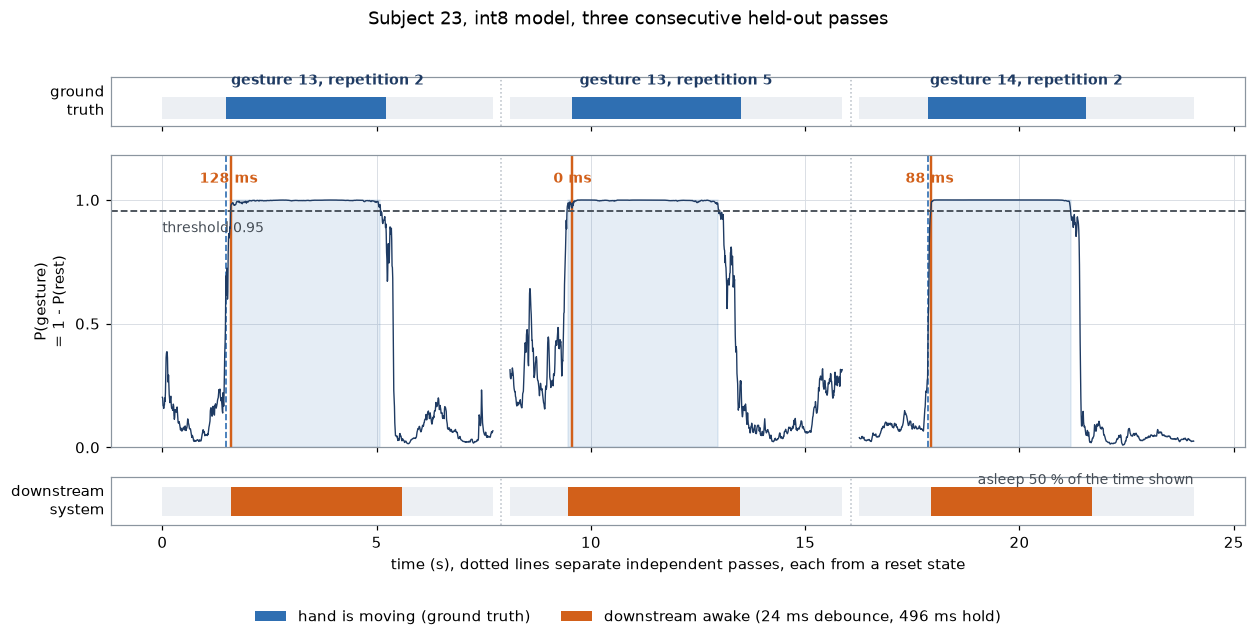

In [23]:
def contiguous_runs(mask):
    """Return (start, stop) index pairs for each contiguous True run in a boolean mask."""
    edges = np.diff(np.concatenate([[0], mask.astype(np.int8), [0]]))
    return list(zip(np.flatnonzero(edges == 1), np.flatnonzero(edges == -1)))


def plot_trigger_timeline(indices, probabilities, labels_per_pass, gestures, repetitions,
                          threshold, debounce_steps, hold_steps):
    """Draw ground truth, P(gesture) and the downstream wake window for several passes.

    Args:
        indices: which passes to draw, in order.
        probabilities: list of (n_steps,) P(gesture) arrays, one per pass.
        labels_per_pass: list of (n_steps,) true class arrays, one per pass.
        gestures: gesture id per pass.
        repetitions: repetition id per pass.
        threshold: P(gesture) at which the trigger fires.
        debounce_steps: consecutive steps required before asserting.
        hold_steps: steps kept awake after the trigger last asserted.
    """
    figure, axes = plt.subplots(3, 1, figsize=(12, 5.6), sharex=True,
                                gridspec_kw={"height_ratios": [0.5, 3, 0.5]})
    offset_s, awake_total, shown_total = 0.0, 0, 0
    gap_s = 0.4

    for position, index in enumerate(indices):
        probability = probabilities[index]
        pass_labels = labels_per_pass[index]
        state = debounced_state(probability >= threshold, debounce_steps)
        awake = with_hold(state, hold_steps)
        awake_total += int(awake.sum())
        shown_total += awake.size
        seconds = offset_s + np.arange(probability.size) * STEP_MS / 1000.0

        axes[0].add_patch(Rectangle((seconds[0], 0.2), seconds[-1] - seconds[0], 0.6,
                                    facecolor=PALETTE["rest"], edgecolor="none"))
        moving = pass_labels != REST
        if moving.any():
            onset, release = seconds[moving][0], seconds[moving][-1]
            axes[0].add_patch(Rectangle((onset, 0.2), release - onset, 0.6,
                                        facecolor=PALETTE["movement"], edgecolor="none"))
            axes[1].axvline(onset, color=PALETTE["movement"], linewidth=1.1, linestyle="--")
            latency = detection_latency_ms(state, pass_labels)
            if not np.isnan(latency):
                axes[1].axvline(onset + latency / 1000.0, color=PALETTE["accent"], linewidth=1.6)
                axes[1].annotate(f"{latency:.0f} ms", xy=(onset + latency / 2000.0, 1.07),
                                 ha="center", fontsize=9, color=PALETTE["accent"],
                                 fontweight="bold")
        axes[0].text((seconds[0] + seconds[-1]) / 2, 1.15,
                     f"gesture {gestures[index]}, repetition {repetitions[index]}",
                     ha="center", fontsize=9, fontweight="bold", color=PALETTE["signal"])

        axes[1].plot(seconds, probability, color=PALETTE["signal"], linewidth=0.9)
        axes[1].fill_between(seconds, 0, 1, where=state, color=PALETTE["movement"], alpha=0.12)
        axes[2].add_patch(Rectangle((seconds[0], 0.2), seconds[-1] - seconds[0], 0.6,
                                    facecolor=PALETTE["rest"], edgecolor="none"))
        for start, stop in contiguous_runs(awake):
            axes[2].add_patch(Rectangle((seconds[start], 0.2),
                                        (stop - start) * STEP_MS / 1000.0, 0.6,
                                        facecolor=PALETTE["accent"], edgecolor="none"))
        if position < len(indices) - 1:
            for axis in axes:
                axis.axvline(seconds[-1] + gap_s / 2, color="#b6bdc5", linewidth=1.0,
                             linestyle=":")
        offset_s = seconds[-1] + gap_s

    axes[0].set_ylim(0, 1.35)
    axes[0].set_yticks([])
    axes[0].set_ylabel("ground\ntruth", rotation=0, ha="right", va="center")
    axes[0].grid(visible=False)

    axes[1].axhline(threshold, color="#444c55", linewidth=1.2, linestyle="--")
    axes[1].text(0.0, threshold - 0.04, f"threshold {threshold:.2f}", va="top", fontsize=9,
                 color="#444c55")
    axes[1].set_ylim(0, 1.18)
    axes[1].set_yticks([0.0, 0.5, 1.0])
    axes[1].set_ylabel("P(gesture)\n= 1 - P(rest)")

    axes[2].set_ylim(0, 1)
    axes[2].set_yticks([])
    axes[2].set_ylabel("downstream\nsystem", rotation=0, ha="right", va="center")
    axes[2].set_xlabel("time (s), dotted lines separate independent passes, each from a reset state")
    axes[2].grid(visible=False)
    axes[2].text(offset_s - gap_s, 0.93,
                 f"asleep {100 * (1 - awake_total / shown_total):.0f} % of the time shown",
                 ha="right", va="center", fontsize=9, color="#444c55")

    figure.legend(handles=[
        Patch(facecolor=PALETTE["movement"], label="hand is moving (ground truth)"),
        Patch(facecolor=PALETTE["accent"], label=f"downstream awake "
              f"({debounce_steps * STEP_MS:.0f} ms debounce, {hold_steps * STEP_MS:.0f} ms hold)"),
    ], loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.03))
    figure.suptitle(f"Subject {SUBJECT}, int8 model, three consecutive held-out passes", y=0.99)
    figure.tight_layout(rect=(0.02, 0.05, 0.98, 0.97))
    plt.show()


plot_trigger_timeline(range(24, 27), probabilities, test["labels"],
                      test["gesture"], test["repetition"],
                      threshold, DEBOUNCE_STEPS, HOLD_STEPS)


**Why a separate trigger is worth building.** The trigger costs nothing extra: it is one
subtraction on an output the model already produces. What it buys is a duty cycle. Only the sensing
path, the TENNs-R model and a small always-on controller need to be powered continuously; the
application processor, the radio and anything else expensive can stay in deep sleep until the
trigger fires, a fraction of a second after a movement begins.

Two honest notes on the numbers above.

- **Read the duty cycle on the rest steps, not on the whole set.** These held-out passes are one
  movement wrapped in rest, so about two thirds of them is movement by construction. That is not a
  day in the life of a wearer, whose hand is at rest almost all the time. The figure that carries
  over is how often the trigger is asserted **while the hand is at rest**, which is what the
  threshold was set to control.
- **The operating point is a dial, not a constant.** A lower false-alarm target wakes the system
  less often but detects later and misses more. Where to set it is a system decision, not a model
  one. Note also that the threshold here is read off the same held-out passes it is then applied
  to, which makes this an illustration of the operating point rather than a held-out measurement of
  it. A product would fit the threshold per user, on the same short calibration recording that
  trains their model.


## 13. Results across all 40 subjects

Everything so far has been one subject, run end to end in this notebook. The numbers below are the
whole cohort: the same architecture, the same recipe and the same protocol, trained and scored once
per subject.


In [24]:
def load_csv(path):
    """Read a small CSV into a list of dicts, keeping the column order of the header."""
    with open(path, newline="") as handle:
        return list(csv.DictReader(handle))


cohort = load_csv(os.path.join(BASE_DIR, "results", "exp12_cohort.csv"))
cohort_float = np.array([float(row["accuracy_float"]) for row in cohort])
cohort_int8 = np.array([float(row["accuracy_int8"]) for row in cohort])

print(f"NinaPro DB2, all {len(cohort)} subjects, 49 gesture classes, chance about 2 %")
print(f"  float : {cohort_float.mean():.2f} %, standard deviation {cohort_float.std(ddof=1):.2f}")
print(f"  int8  : {cohort_int8.mean():.2f} %, standard deviation {cohort_int8.std(ddof=1):.2f}")
print(f"  quantization costs {cohort_float.mean() - cohort_int8.mean():.2f} points on average")
print(f"  per-subject range, int8: {cohort_int8.min():.1f} % to {cohort_int8.max():.1f} %")
print(f"  subject {SUBJECT}, reproduced in this notebook: "
      f"{int8_scores['acc_49'] * 100:.2f} % int8, {float_scores['acc_49'] * 100:.2f} % float")


NinaPro DB2, all 40 subjects, 49 gesture classes, chance about 2 %
  float : 85.39 %, standard deviation 4.40
  int8  : 85.31 %, standard deviation 4.37
  quantization costs 0.08 points on average
  per-subject range, int8: 75.7 % to 92.7 %
  subject 23, reproduced in this notebook: 86.82 % int8, 86.85 % float


### Figure: accuracy against model size, against the published DB2 literature

Parameter count is the one cost axis the whole field reports, so it is the axis this comparison
uses. Every other point is float; ours is the int8 model that would actually be deployed.


![Bubble chart of subject-averaged accuracy against trainable parameter count on a log axis, for the published NinaPro DB2 models listed below and for the int8 TENNs-R model, which is highlighted at 96k parameters. Bubble area scales with parameter count.](img/accuracy_vs_parameters.png)

The published results behind that chart, transcribed from the cited papers:

| Model | Accuracy | Classes | Parameters | Source |
|---|---:|---:|---:|---|
| TraHGR-Base | 78.60 % | 49 | 83,731 | Zabihi et al., 2022 |
| TraHGR-FNet | 80.72 % | 49 | 366,673 | Zabihi et al., 2022 |
| TraHGR-large | 83.58 % | 49 | 316,051 | Zabihi et al., 2022 |
| TraHGR-TNet | 83.39 % | 49 | 472,513 | Zabihi et al., 2022 |
| TraHGR-Huge | 86.18 % | 49 | 846,579 | Zabihi et al., 2022 |
| NKDFF-CNN | 88.03 % | 49 | 620,000 | as tabulated by He et al., 2026 |
| MvCNN | 85.80 % | 50 \* | 4,030,000 | as tabulated by He et al., 2026 |
| MSDS-FusionNet | 90.15 % | 49 | 3,710,000 | He et al., 2026 |
| Random forest (dataset paper) | 75.27 % | 50 \* | not reported | Atzori et al., 2014 |

\* scored over 50 classes rather than 49.

### Reading that chart honestly

At **96,128 parameters** TENNs-R sits **above TraHGR-large (316k) and TraHGR-TNet (473k)**, which
are three to five times its size, and within about a point of **TraHGR-Huge (847k)** at roughly a
ninth of the parameters. The two points above it, NKDFF-CNN at 620k and MSDS-FusionNet at 3.71M,
are six and thirty-nine times larger.

**And the comparison is not like for like.** It must not be presented as one.

- **Ours is int8, theirs is float.** We measured that gap rather than hiding it: 0.08 points on the
  cohort.
- **We carry a rest class and they do not.** That is a capability, not a handicap, but it comes
  with a metric nobody else reports. On subject 23 the model names a gesture on
  about a fifth of rest steps under a plain argmax, which is exactly the number the trigger in
  section 12 exists to manage, and why `acc_49` should never be quoted on its own.
- **Everybody here is subject-dependent.** Ours, and every published number on this chart, assumes
  a per-user calibration.

The defensible claim is the one the chart makes on its own axis: **at a small fraction of the
parameters, scored on a continuous stream rather than on pre-cut windows, and already quantized,
TENNs-R lands in the same accuracy band as transformer models several times its size.**


## 14. Why this matters for the system

Pull the threads together, from the point of view of someone building the product rather than the
model.

**Memory and compute do not grow with time.** The deployed model carries 1,792 bytes of recurrent
state and one 8 ms input chunk. Whether the device has been running for a second or a week, that is
the whole footprint, and the cost of the next decision is identical. There is no window to
re-buffer and no history to keep.

**There is no front end to pay for.** No FFT, no MFCC, no filter bank, no feature extraction, no
window assembly ahead of inference. The model consumes the sampled waveform directly, so the
preprocessing block disappears from the compute budget and from the bill of materials.

**The expensive parts of the system can sleep.** The trigger is one subtraction on an output the
model already emits. Everything downstream, the application processor, the radio, the display, can
stay in deep sleep until it fires, and on this subject's held-out data it detected every movement
with a median latency of a quarter of a second while staying quiet through most of the rest.

**Each sample is touched once.** A sliding-window model re-reads every sample once per window it
belongs to, so its arithmetic repeats as often as its windows overlap. The recurrence reads each
sample once. That difference does not show up in an accuracy table, and it shows up in every
energy budget.

**It is small enough to argue about in kilobytes.** Around 90 KiB of int8 weights, under 2 kB of
live state, and a decision rate of 125 per second. Those are the numbers to take into a hardware
conversation.


## 15. References

**Dataset and protocol**

- Atzori et al., *Electromyography data for non-invasive naturally-controlled robotic hand
  prostheses*, Scientific Data 1:140053, 2014. DOI 10.1038/sdata.2014.53. The DB2 dataset paper.
  It defines the acquisition, the realigned label track, the train 1/3/4/6 and test 2/5 split used
  throughout this notebook, and reports a random-forest baseline of 75.27 % over 50 classes.
- The NinaPro project and its download terms: `https://ninapro.hevs.ch`. Subject archives are
  public, at `https://ninapro.hevs.ch/files/DB2_Preproc/DB2_s<N>.zip`, a few hundred megabytes
  each. Please read NinaPro's own terms of use before redistributing any part of the data.

**Published DB2 results used in the comparison**

- Zabihi, Rahimian, Asif and Mohammadi, *TraHGR: Transformer for Hand Gesture Recognition via
  Electromyography*, arXiv:2203.16336, 2022. Source of the TraHGR-Base, FNet, TNet, large and Huge
  accuracies and parameter counts.
- Rahimian et al., *TEMGNet: Deep Transformer-based Decoding of Upper-limb sEMG for Hand Gesture
  Recognition*, arXiv:2109.12379, 2021. A transformer at the small end of the parameter range,
  scored over 17 classes rather than 49.
- He et al., *A multi-scale dual-stream fusion network for high-accuracy sEMG-based gesture
  classification*, Scientific Reports, 2026. Source of the MSDS-FusionNet result, and of the
  tabulated NKDFF-CNN and MvCNN figures used in the comparison.
- EMGBench, *Benchmarking Out-of-Distribution Generalization and Adaptation for Electromyography*,
  NeurIPS Datasets and Benchmarks, 2024. A useful reference for what sEMG accuracy looks like
  without the per-user calibration every number here assumes.

**BrainChip**

- Akida and MetaTF documentation, including the Akida Pico pages:
  `https://doc.brainchipinc.com/index.html`.
- The other examples in this repository, `examples/kws/` and `examples/fault_detection/`, run the
  same TENNs pipeline end to end on Akida Pico FPGA hardware and do report on-device throughput and
  power.
